# Assignment 4
 - a) We will be working with the **AFHQ (Animal Faces-HQ)** dataset: https://github.com/clovaai/stargan-v2
    - Approx 15.000 images of animal faces (cat, dog, tiger, ...)
    - Downsample the images to 64x64
 - b) Write **Convolutional** Variational Autoencoder (ConvVAE)
      - Use Conv. layers for encoder and Transposed-Conv. layers for decoder.
      - You are only allowed to use linear layers for estimating the mean and standard deviation. Everything else should be convolutional.
 - c) Investigate the importance of the KL-divergence weight. For this purpose, train multiple models (at least 4) using different weighting values and investigate how this value affects the generation performance.
 - d) Generate new images by sampling latent vectors, investigate latent space and visualize some interpolations.
 - e) Compare the models from b) and c)
     - Qualitative comparison. Which images look better?
     - Quantitative comparison between models using the Fréchet Inception Distance: https://arxiv.org/abs/1706.08500
     - Log generated images and losses into the Tensorboard/W&B
     
     
**Extra Point:**
 - Extend your ConvVAE for Image generation conditioned on a given class. The AFHQ dataset has 3 classes: 'cat', 'dog', and 'wildlife'
 - Train your Conditional-ConvVAE
 - Show that you can generate images conditioned on a label
 - Tutorial: https://ijdykeman.github.io/ml/2016/12/21/cvae.html

In [ ]:
import os  
import shutil
from tqdm import tqdm
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from pytorch_lightning import seed_everything
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, models, transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader
from utils import *

from torch.utils.tensorboard import SummaryWriter

In [2]:
%load_ext autoreload
%autoreload 1

1. ### Experiment with `KLD = 1e_3`

In [3]:
configs = {   
    "model_name" : "CVAE",
    "exp" : "1",  
    "latent_dim" : 64,
    "batch_size" : 64,
    "num_epochs" : 50,
    "lr" : 1e-3,
    "scheduler" : "ReduceLROnPlateau",
    "use_scheduler" : True,
    "lambda_kld" : 1e-3,
    }

In [4]:
dataset_root = './data/AFHQ/'

transform = transforms.Compose([transforms.Resize((64,64)),
                                      transforms.ToTensor(),
                                      transforms.Normalize([0.5]*3 , [0.5]*3)])

BS = configs["batch_size"]

train_dataset = datasets.ImageFolder(root= dataset_root+'train', transform= transform )
test_dataset = datasets.ImageFolder(root= dataset_root+'test', transform= transform )

# print(train_dataset.classes)  
print(train_dataset.class_to_idx)  

train_loader = DataLoader(dataset= train_dataset, 
                          batch_size= BS, 
                          shuffle= True, 
                          drop_last= True )

test_loader = DataLoader(dataset= test_dataset, 
                          batch_size= BS, 
                          shuffle= False, 
                          drop_last= True )

{'cat': 0, 'dog': 1, 'wild': 2}


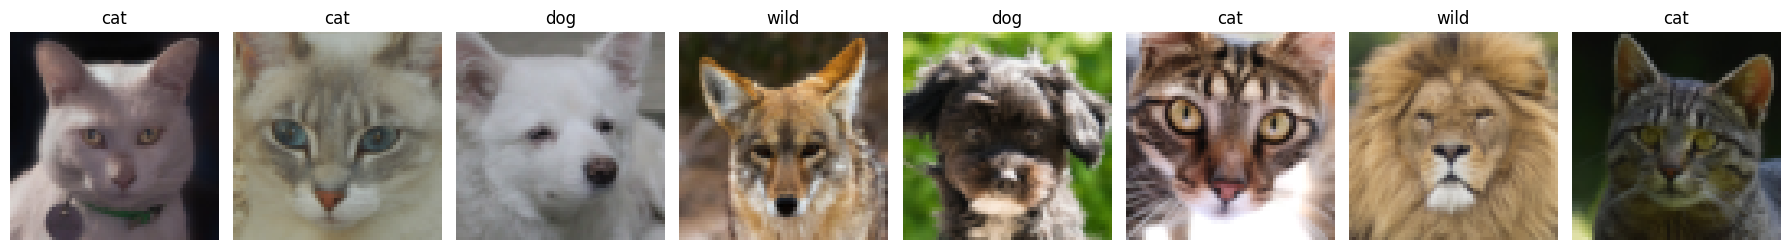

In [5]:
imgs, labels = next(iter(train_loader))
fig, ax = plt.subplots(1, 8)
fig.set_size_inches(18, 5)
for i in range(8):
    img_np = imgs[i].permute(1, 2, 0).numpy()
    # Denormalize the image
    img_np = (img_np * 0.5 + 0.5).clip(0, 1)
    ax[i].imshow(img_np)
    ax[i].axis("off")
    ax[i].set_title(f"{train_dataset.classes[labels[i]]}")
plt.tight_layout()
plt.show()

In [6]:
imgs.shape

torch.Size([64, 3, 64, 64])

In [7]:
class CVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=64):
        super(CVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.in_channels = in_channels
        
        # Encoder
        self.encoder = self.make_encoder()
        
        # Fully connected layers for mu and sigma
        self.fc_mu = nn.Linear(2048, latent_dim)
        self.fc_sigma = nn.Linear(2048, latent_dim)
        
        '''
        Also called projection layer, projects latent vector to  original dimensionality.
        maps the latent variable into a space compatible with the decoder input
        '''
        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 2048),
            nn.LeakyReLU(0.2)
        )
        
        # Decoder
        self.decoder = self.make_decoder()

    def make_encoder(self):
        
        return nn.Sequential(
            # Input: (3, 64, 64)
            nn.Conv2d(self.in_channels, 16, kernel_size=4, stride=2, padding=1),  # (16, 32, 32)
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),  # (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            
            nn.Flatten()  # 128 * 4 * 4 = 2048
        )
        
    def make_decoder(self):
        return nn.Sequential(
            # Input: (128, 4, 4)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # (16, 32, 32)
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2),
            
            nn.ConvTranspose2d(16, self.in_channels, kernel_size=4, stride=2, padding=1),  # (3, 64, 64)
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        """Reparameterization trick"""
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def forward(self, x):
        # Encode
        x_encoded = self.encoder(x)
        
        # Get mu and log_var
        mu = self.fc_mu(x_encoded)  # [batch_size, latent_dim]
        log_var = self.fc_sigma(x_encoded)  # [batch_size, latent_dim]
        
        # Reparameterization trick
        z = self.reparameterize(mu, log_var)  # [batch_size, latent_dim]
        
        # Project and reshape for decoder
        z = self.decoder_input(z)
        z = z.view(-1, 128, 4, 4)
        x_hat = self.decoder(z)
        
        return x_hat, (z, mu, log_var) 
    

## $Note\ on\ network\ architecture$

- We experimented with various network configs. From increasing the latent space dimention up to 512, to more powerfun CNN endoder/decoders, to linear layers up to 8192 neurons. 

- As discussed per email, we also tried with latent space 128 and encoder layers [64, 128, 256, 512]. Results can be found under *CVAE_new1_KLD_0.0001*.

- Nevertheless, the recons, altough marginal, were not noticeably improved! Therefor, we kept out network to the current settings, with parameters being significantly fewer. 

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

seed_everything(42)

model = CVAE(latent_dim=configs["latent_dim"]).to(device)


Seed set to 42


In [53]:
model

CVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=2048, out_features=64, bias=True)
  (fc_sigma): Linear(in_features=2048, out_

In [11]:
count_model_params(model.encoder)

173520

In [12]:
count_model_params(model.decoder)

173139

In [13]:
count_model_params(model.fc_mu) + count_model_params(model.fc_sigma) 

262272

In [14]:
count_model_params(model)

742051

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=configs["lr"], weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5, verbose=True)

/home/user/soltania1/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [16]:
def makedires(configs):
    model_name = configs["model_name"]+configs["exp"]+f"_KLD_{configs['lambda_kld']}"
    savepath = f"imgs/{model_name}"
    if os.path.exists(savepath):
        shutil.rmtree(savepath)
    os.makedirs(savepath,exist_ok=True)

    TBOARD_LOGS = os.path.join(os.getcwd(), "tboard_logs", model_name+f"_KLD_{configs['lambda_kld']}")
    if os.path.exists(TBOARD_LOGS):
        shutil.rmtree(TBOARD_LOGS)
    os.makedirs(TBOARD_LOGS)
    writer = SummaryWriter(TBOARD_LOGS)
    return savepath, writer

savepath, writer = makedires(configs)

In [17]:
def vae_loss_function(recons, target, mu, log_var, lambda_kld=configs["lambda_kld"]):
    """
    Combined loss function for joint optimization of 
    reconstruction and ELBO
    """
    recons_loss = F.mse_loss(recons, target)
    kld = (-0.5 * (1 + log_var - mu**2 - log_var.exp()).sum(dim=1)).mean(dim=0)  # closed-form solution of KLD in Gaussian
    loss = recons_loss + lambda_kld * kld

    return loss, (recons_loss, kld)

In [ ]:
model_name = configs["model_name"]+configs["exp"]+f"_KLD_{configs['lambda_kld']}"

train_loss, val_loss, loss_iters, val_loss_recons, val_loss_kld = train_model(
        model=model, 
        model_name=model_name,
        optimizer=optimizer,
        scheduler=scheduler if configs["use_scheduler"] else None, 
        criterion=vae_loss_function,
        lambda_kld=configs["lambda_kld"],
        train_loader=train_loader, 
        valid_loader=test_loader, 
        num_epochs=configs["num_epochs"],
        save_frequency= 10, 
        savepath=savepath,
        writer=writer
    )

### Saving model and training configs

In [19]:
def save_config(configs):
    model_name = configs["model_name"]+configs["exp"]+f"_KLD_{configs['lambda_kld']}"
    configs_dir = f"./configs/{model_name}/"
    if not os.path.exists(configs_dir):
        os.makedirs(configs_dir,exist_ok=True)
    configs_path = configs_dir + "/config.yaml"

    with open(configs_path, 'w') as f:
        yaml.dump(configs, f)

epoch = configs["num_epochs"]
lambda_kld = configs["lambda_kld"]

save_model(model, model_name, optimizer, epoch = epoch,lambda_kld = lambda_kld, stats = configs )
save_config(configs)


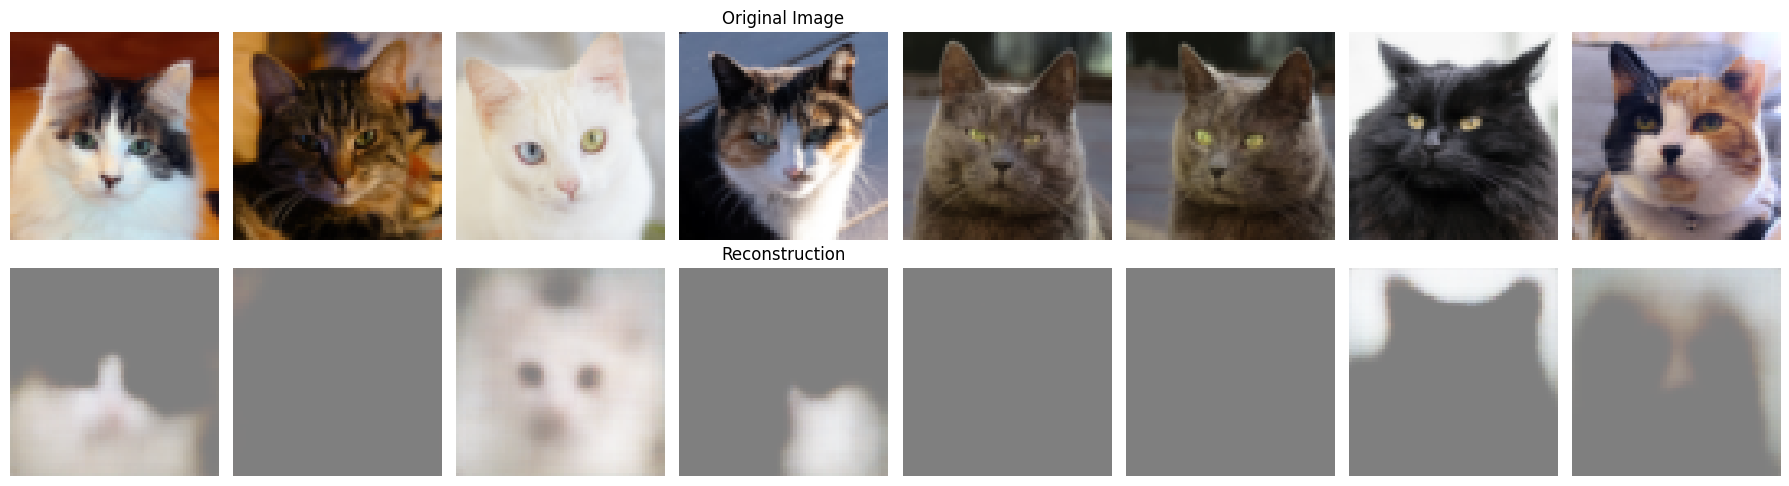

In [20]:
img_vs_recons(model, test_loader, device)

In [27]:
def compute_encoder_output_size(batch_size, input_shape, model):
    """
    Compute the un/flattened output size of the encoder given an input shape.
    """
    with torch.no_grad():

        enc_input = torch.zeros(batch_size, *input_shape).to(device)  # (BS, 3, 64, 64)
        
        # Get encoder output
        output = model.encoder(enc_input)
        
        enc_out_shape = output.view(batch_size,-1,4,4).shape[1:]
        # Get flattened size
        flattened_size = output.view(1, -1).shape[1]
        return enc_out_shape, flattened_size
        

In [28]:
compute_encoder_output_size(BS, (3, 64, 64), model)

(torch.Size([128, 4, 4]), 131072)

## Inference 

Sampling random tensors from a normal districution and investigating if the model has learnt to map any random vercor with normal distribution to a meaningful resresentation

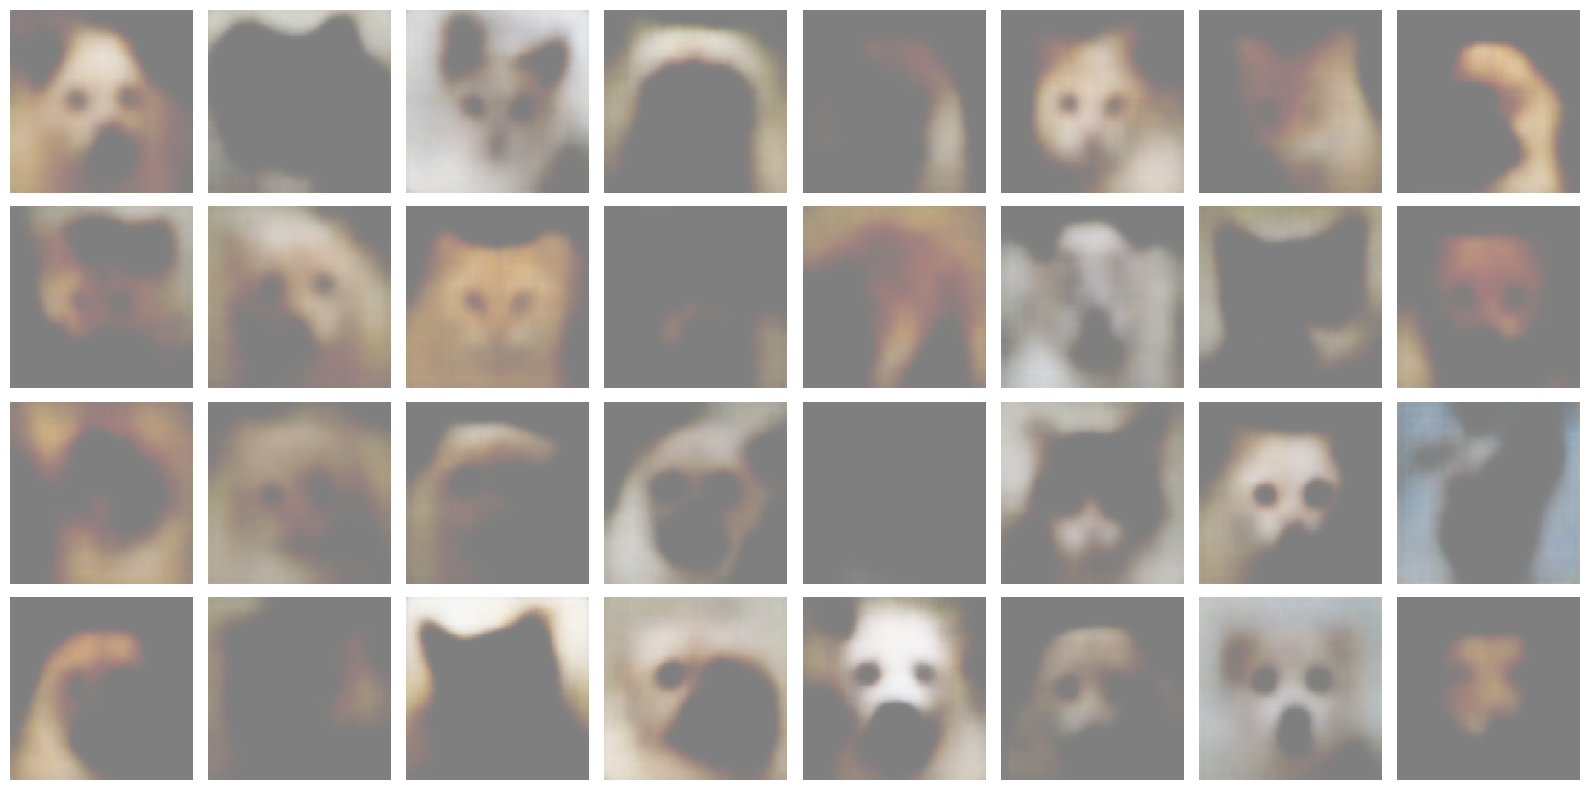

In [29]:
def inference(configs, model):
    model_name = configs["model_name"]+configs["exp"]+f"_KLD_{configs['lambda_kld']}"
    BS = configs["batch_size"]
    if not os.path.exists(f"imgs/inference/{model_name}"):
        os.makedirs(f"imgs/inference/{model_name}")

    latent_dim = configs["latent_dim"]

    enc_output_shape, _ = compute_encoder_output_size(BS, (3, 64, 64), model)
    # print(enc_output_shape)
    with torch.no_grad():
        for i in range(5):
            z = torch.randn(BS, latent_dim).to(device)

            z = model.decoder_input(z)
            z = z.view(-1, *enc_output_shape)

            recons = model.decoder(z)
            recons = recons.view(BS, 3, 64, 64)
            save_image(recons, f"imgs/inference/{model_name}/inference_{i}.png")
            return recons

def plot_recons(recons):
    plt.figure(figsize=(8*2, 4*2))
    for i in range(32):
        plt.subplot(4,8,i+1)
        recon_img = denormalize_images(recons[i].cpu())
        # recon_img = recons[i].cpu()
        recon_img = recon_img.permute(1, 2, 0)
        plt.imshow(recon_img)  
        plt.axis("off")
    plt.tight_layout()
    plt.show()
    
    
plot_recons(inference(configs,model))


### Latent space  visualization

In [25]:
def vis_latent(test_loader, model, test_dataset):
    imgs_flat, latents, labels = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs = imgs.to(device)
            _, (z, _, _) = model(imgs)
            imgs_flat.append(imgs.cpu().view(imgs.shape[0],-1))
            latents.append(z.cpu())
            labels.append(lbls)
            
    imgs_flat = np.concatenate(imgs_flat)    
    latents = np.concatenate(latents)
    labels = np.concatenate(labels)

    latents_reshaped = latents.reshape(latents.shape[0], -1)

    pca_imgs = PCA(n_components=2).fit_transform(imgs_flat)
    pca_latents = PCA(n_components=2).fit_transform(latents_reshaped)

    N = 2000
    fig,ax = plt.subplots(1,2,figsize=(26,8))
    display_projections(pca_imgs[:N], labels[:N], ax=ax[0], legend=test_dataset.classes)
    ax[0].set_title("PCA Proj. of Images")
    display_projections(pca_latents[:N], labels[:N], ax=ax[1], legend=test_dataset.classes)
    ax[1].set_title("Encoded Representations")
    plt.show()

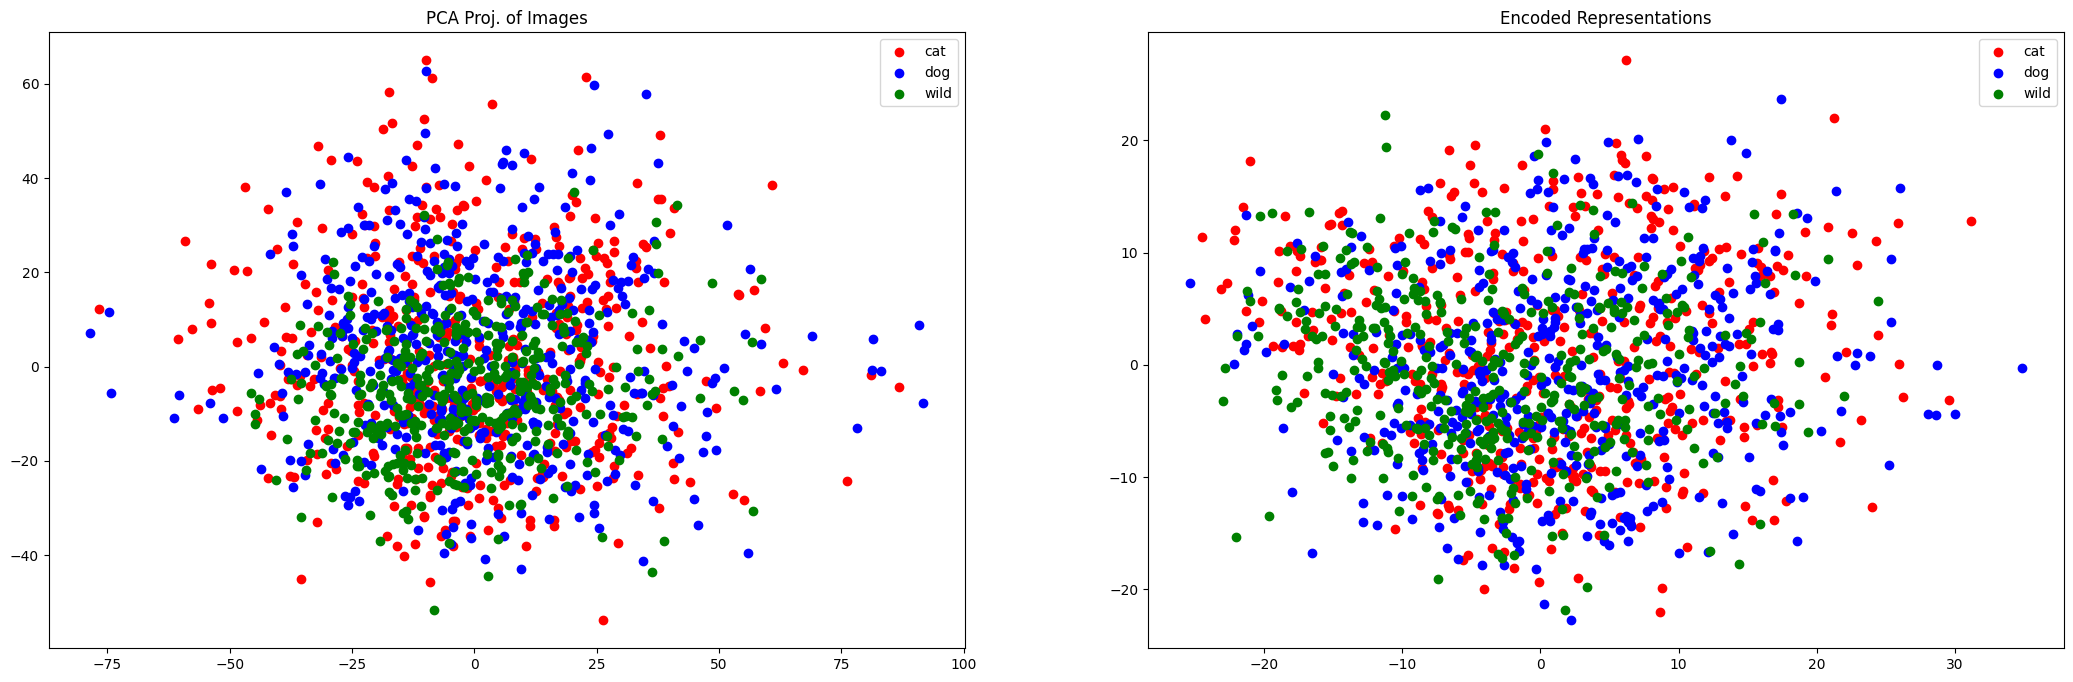

In [26]:
vis_latent(test_loader, model, test_dataset)

## Interpolation

1. The latent space is a compressed representation of images
By sampling different points, we can see how the decoder maps these points to images

2. Interpolation helps us understand what the model has learned and to verify if the model has learned meaningful features

3. Can be used for visualization of the Model's Behavior, how the model generalizes to new inputs

4. Reveals the structure of the learned latent space

5. Interpolation and Generation:
By `sampling normal distributions with linspace mean and std values`, we can move through the latent space
and realize how the model generate new images. 

In [50]:
@torch.no_grad()
def plot_reconstructed(model, xrange=(-3, 3), yrange=(-10, 10), N=12):
    """
    Sampling equispaced points from the latent space given the xrange and yrange, 
    decoding latents and visualizing distribution of the space
    """
    # Project points to decoder input dimension (same as in forward pass)
    SIZE = 64  # Image size
    grid = np.empty((N*SIZE, N*SIZE, 3))  # 3 channels for RGB
    
    for i, y in enumerate(np.linspace(*yrange, N)):
        for j, x in enumerate(np.linspace(*xrange, N)):
            # mean
            mu = torch.zeros(model.latent_dim, device=device)
            mu[0] = x
            mu[1] = y
            
            # standard deviation
            # Create a vector of stds the same shape as mu
            sigma = 1 
            std = torch.full_like(mu, sigma)
            z = torch.normal(mean=mu, std=std)
            
            # Passing through the decoder 
            z = model.decoder_input(z)
            z = z.view(-1, 128, 4, 4)  # Reshape to match decoder input
            
            # Getting recons
            x_hat = model.decoder(z)
            
            # To visualize
            x_hat = x_hat.squeeze(0).cpu()  # Remove batch dimension
            x_hat = x_hat.permute(1, 2, 0)  # (C,H,W) to (H,W,C)
            recon_img = x_hat.numpy()
            
            # Prepare the image for visualization
            recon_img = denormalize_images(recon_img[i])
            
            grid[(N-1-i)*SIZE:(N-i)*SIZE, j*SIZE:(j+1)*SIZE] = recon_img
           
    plt.figure(figsize=(12,20))
    plt.imshow(grid, extent=[*yrange, *xrange])
    plt.axis("off")
    plt.show()

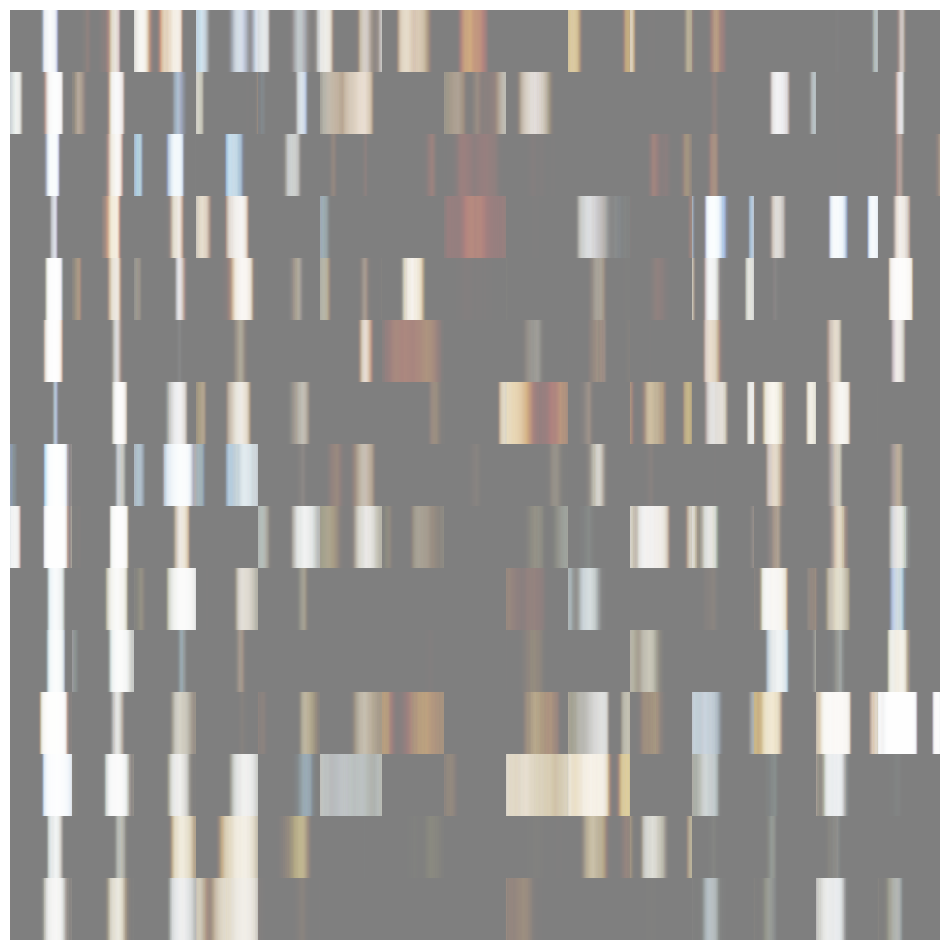

In [52]:
plot_reconstructed(model, xrange=(-10, 10), yrange=(-10, 10), N=15)

### Investigating the importance of the KL-divergence

In VAEs, the loss is:
**Total Loss = Reconstruction Loss + λ * KLD**

Reconstruction Loss (e.g. MSE): Measures how well the VAE reconstructs the input.

KLD: Encourages the latent space distribution to be close to a standard normal (regularization).

However, there is a the trade-off between:

1. Accurate reconstructions (low MSE)
2. Structured latent space (low KLD)

If:

lambda_kld is too low → poor latent structure (overfit to data, bad generative quality)

lambda_kld is too high → poor reconstructions (model ignores input to match prior)

For this assignment we chose following values to experiment with:

lambda_kld_values = [0.0, 1e-4, 1e-3, 1e-2]

| λ (KLD weight) | Effect                                                      |
| -------------- | ----------------------------------------------------------- |
| `0.0`          | Pure autoencoder (no latent regularization)                 |
| `1e-4`         | Very weak KLD → good reconstructions, weak latent structure |
| `1e-3`         | Balanced trade-off                                          |
| `1e-2`         | Strong KLD → worse recons, better sampling and latent space |



2. ### Experiment with `KLD = 0.0`

In [ ]:

seed_everything(42)

model = CVAE(latent_dim=configs["latent_dim"]).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=configs["lr"], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5, verbose=True)
model_name = configs["model_name"]+configs["exp"]+f"_KLD_{configs['lambda_kld']}"
savepath, writer = makedires(configs)

train_loss, val_loss, loss_iters, val_loss_recons, val_loss_kld = train_model(
        model=model, 
        model_name=model_name,
        optimizer=optimizer,
        scheduler=scheduler if configs["use_scheduler"] else None, 
        criterion=vae_loss_function,
        lambda_kld=configs["lambda_kld"],
        train_loader=train_loader, 
        valid_loader=test_loader, 
        num_epochs=configs["num_epochs"],
        save_frequency= 10, 
        savepath=savepath,
        writer=writer
    )

epoch = configs["num_epochs"]
lambda_kld = configs["lambda_kld"]

save_model(model, model_name, optimizer, epoch = epoch,lambda_kld = lambda_kld, stats = configs )
save_config(configs)


### Images vs recons

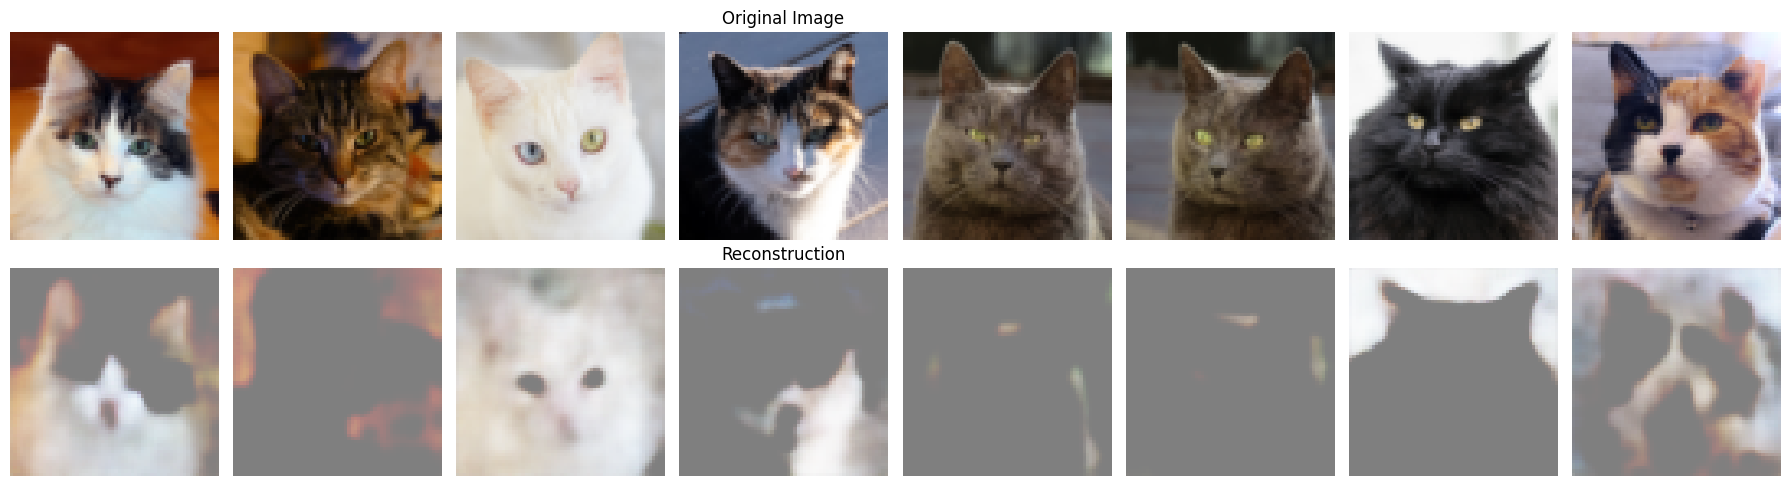

In [5]:
img_vs_recons(model, test_loader, device)

### Inference

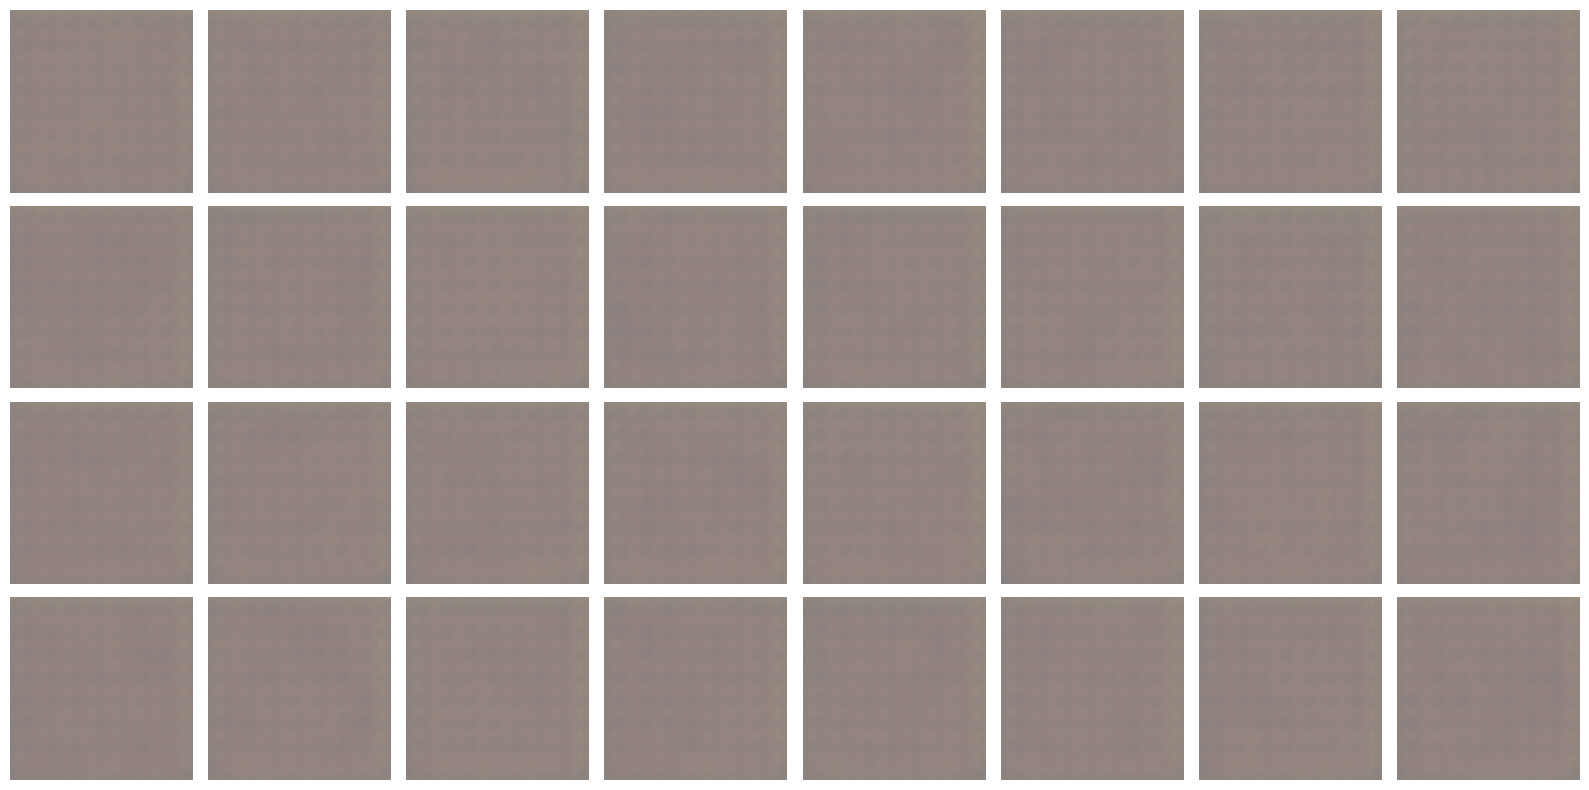

In [6]:
plot_recons(inference(configs,model))


### Latent space  visualization

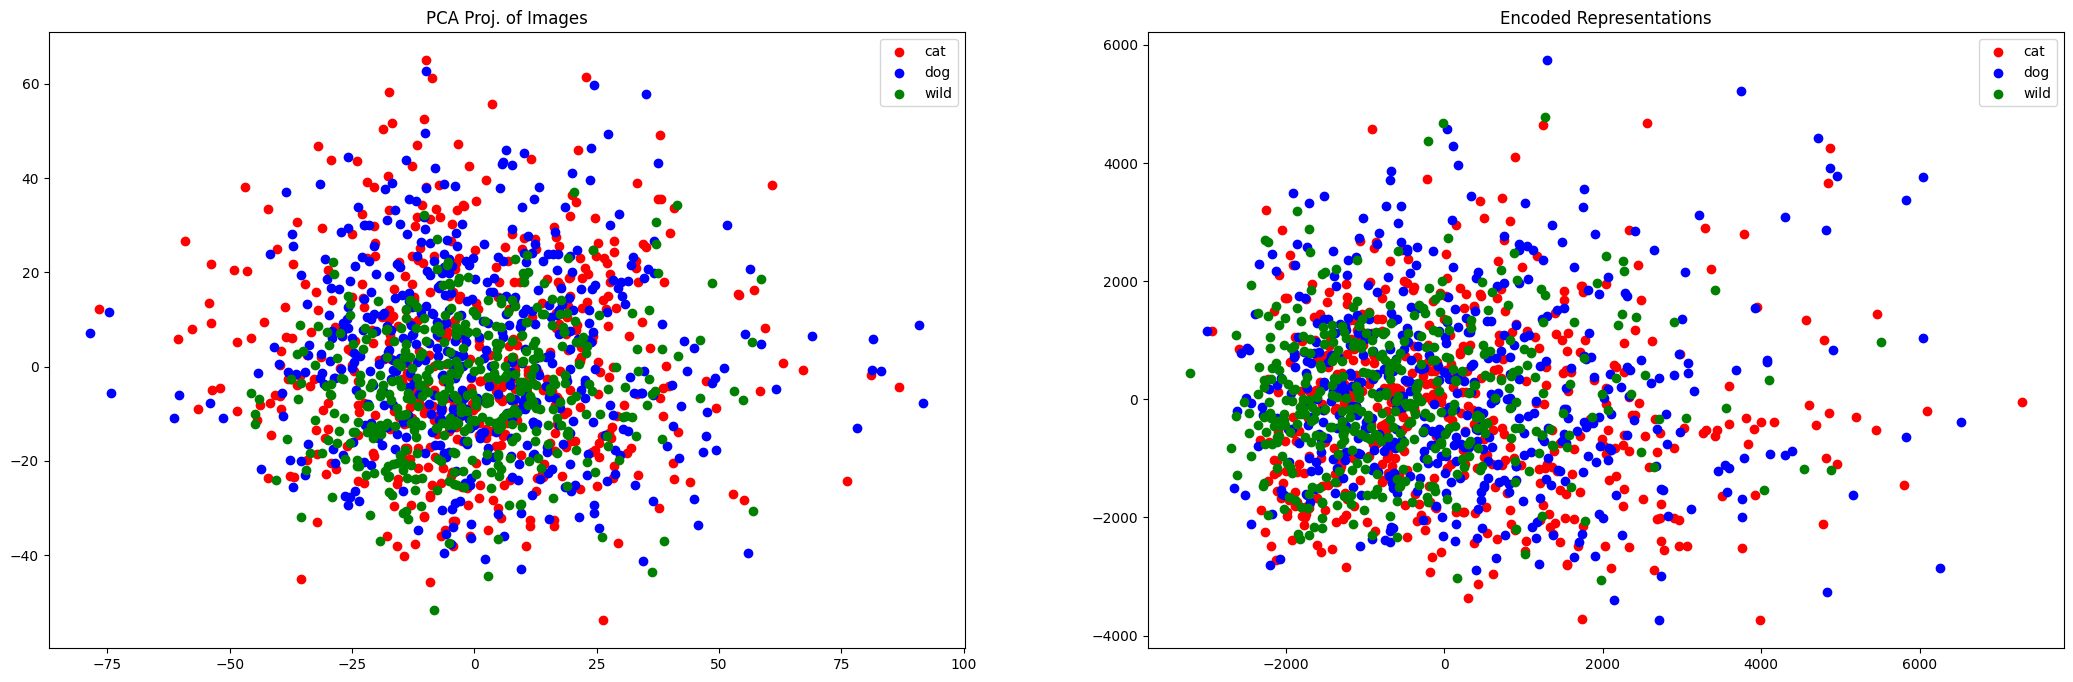

In [7]:
vis_latent(test_loader, model, test_dataset)

### Interpolation

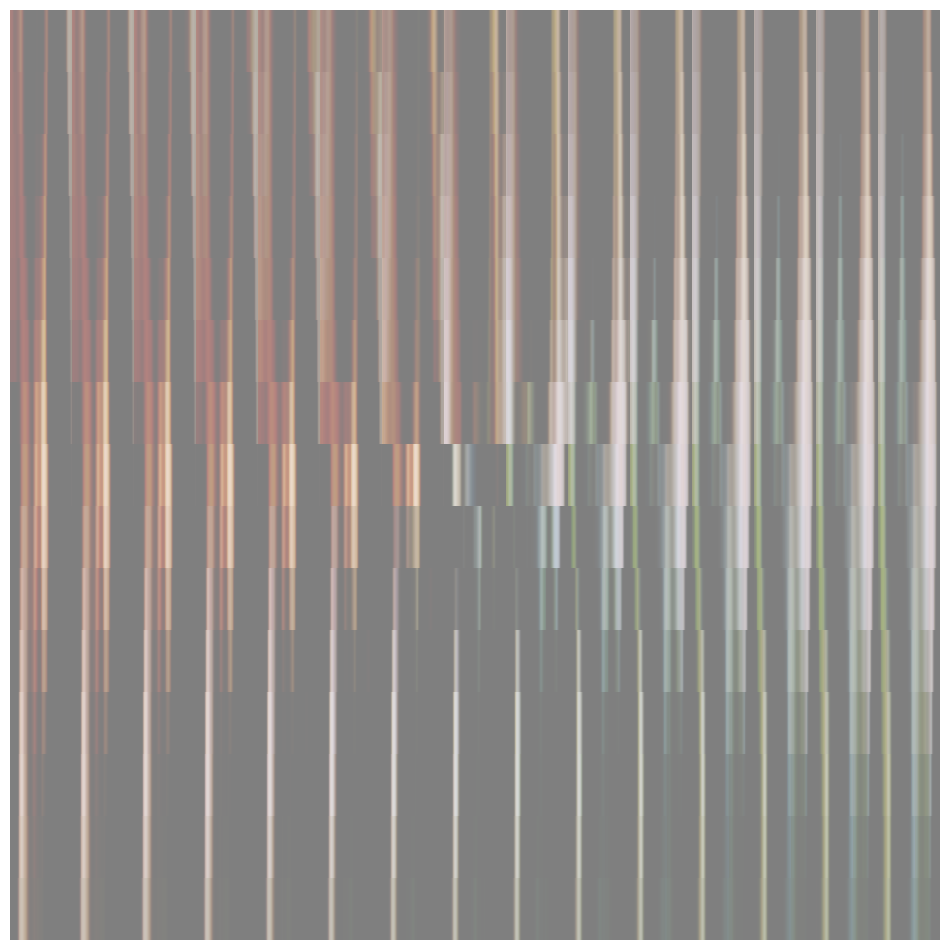

In [5]:
plot_reconstructed(model, xrange=(-2000, 2000), yrange=(-2000, 2000), N=15)

3. ### Experiment with `KLD = 1e_2`

In [ ]:

seed_everything(42)

model = CVAE(latent_dim=configs["latent_dim"]).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=configs["lr"], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5, verbose=True)
model_name = configs["model_name"]+configs["exp"]+f"_KLD_{configs['lambda_kld']}"
savepath, writer = makedires(configs)

train_loss, val_loss, loss_iters, val_loss_recons, val_loss_kld = train_model(
        model=model, 
        model_name=model_name,
        optimizer=optimizer,
        scheduler=scheduler if configs["use_scheduler"] else None, 
        criterion=vae_loss_function,
        lambda_kld=configs["lambda_kld"],
        train_loader=train_loader, 
        valid_loader=test_loader, 
        num_epochs=configs["num_epochs"],
        save_frequency= 10, 
        savepath=savepath,
        writer=writer
    )

epoch = configs["num_epochs"]
lambda_kld = configs["lambda_kld"]

save_model(model, model_name, optimizer, epoch = epoch,lambda_kld = lambda_kld, stats = configs )
save_config(configs)


### Images vs recons

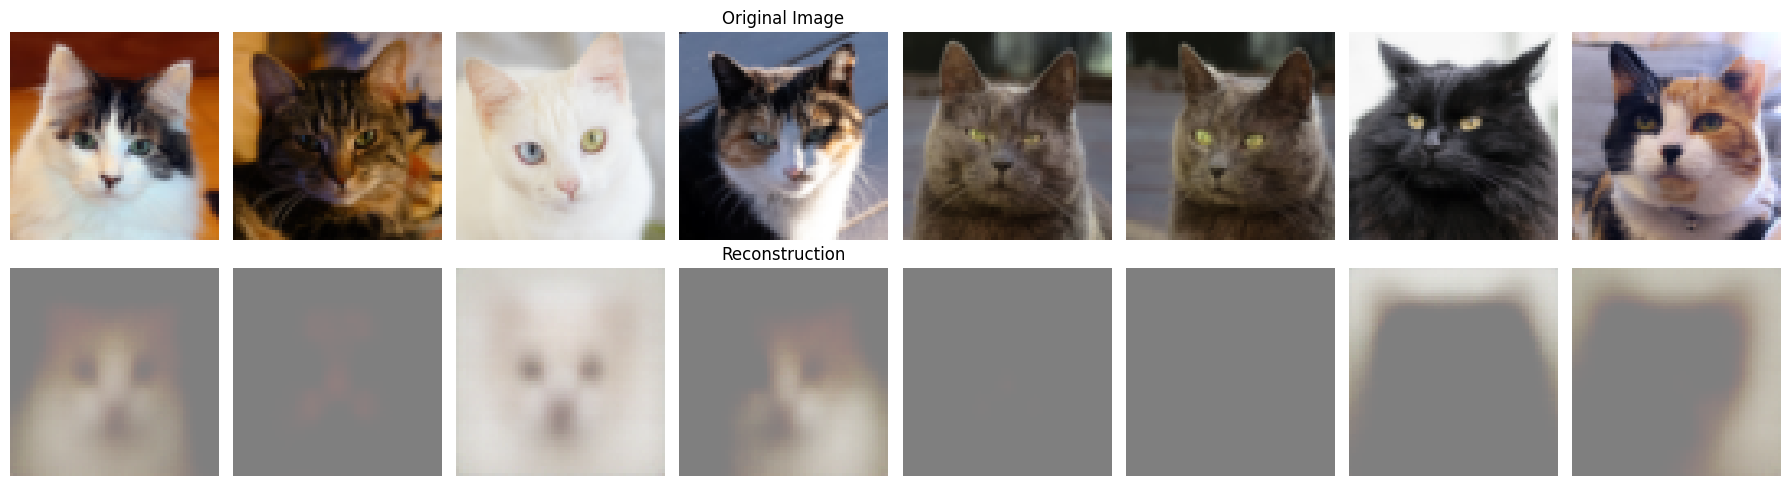

In [5]:
img_vs_recons(model, test_loader, device)

### Inference

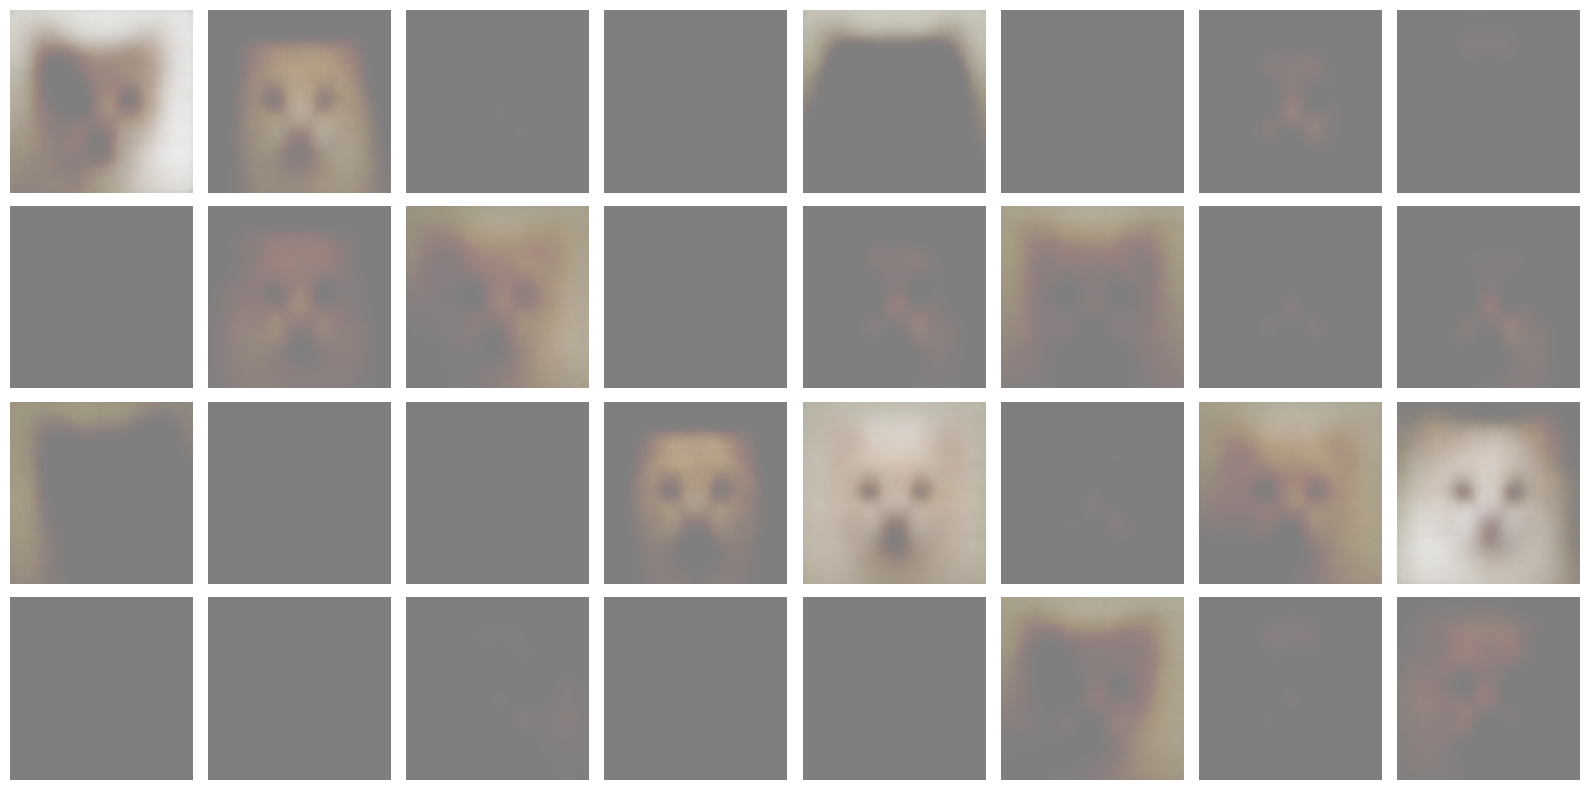

In [6]:
plot_recons(inference(configs,model))


### Latent space  visualization

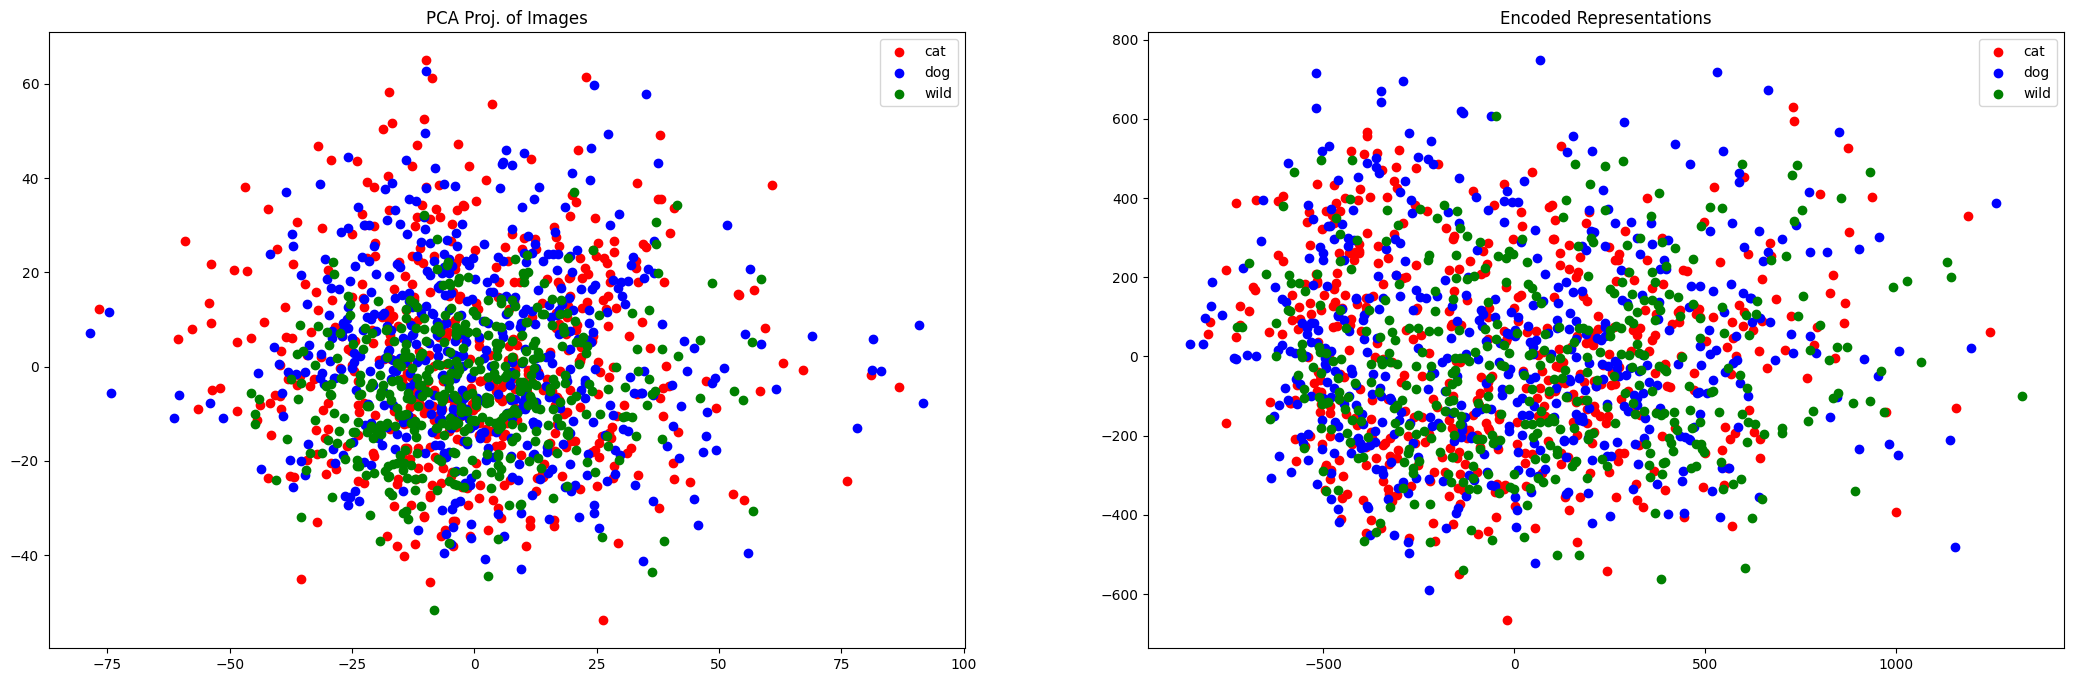

In [7]:
vis_latent(test_loader, model, test_dataset)

### Interpolation

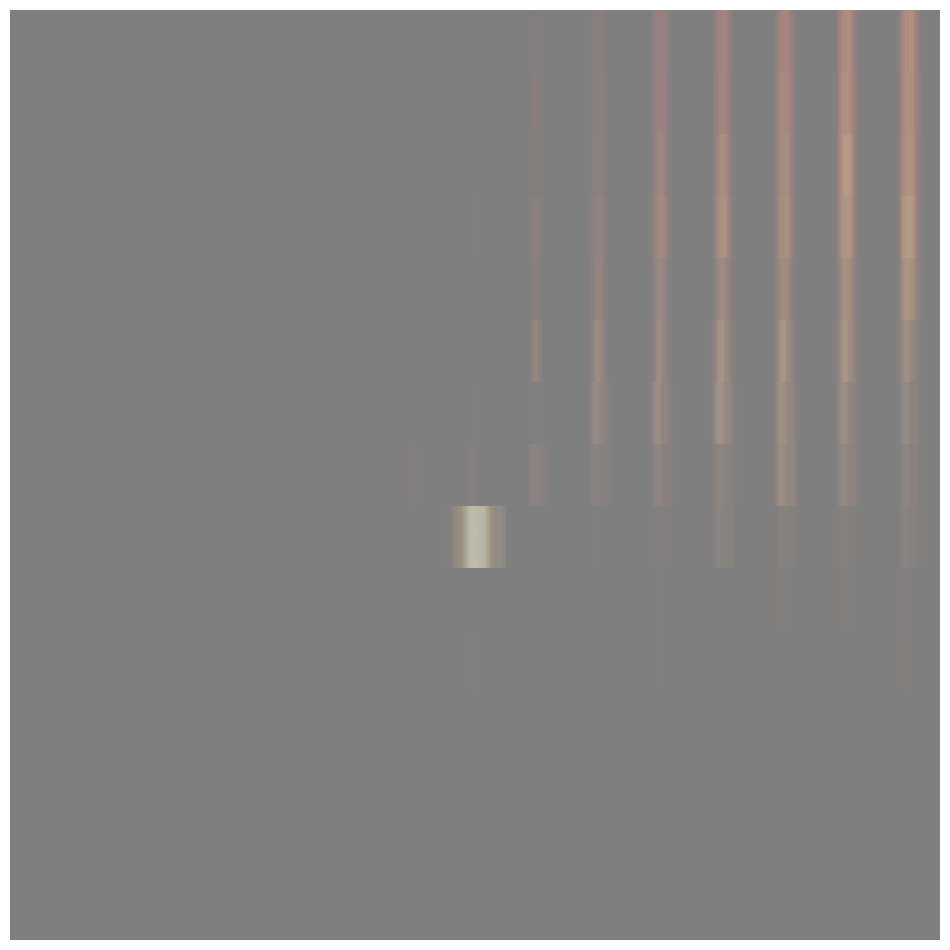

In [5]:
plot_reconstructed(model, xrange=(-400, 400), yrange=(-400, 400), N=15)

4. ### Experiment with `KLD = 1e_4`

In [ ]:

seed_everything(42)

model = CVAE(latent_dim=configs["latent_dim"]).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=configs["lr"], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5, verbose=True)
model_name = configs["model_name"]+configs["exp"]+f"_KLD_{configs['lambda_kld']}"
savepath, writer = makedires(configs)

train_loss, val_loss, loss_iters, val_loss_recons, val_loss_kld = train_model(
        model=model, 
        model_name=model_name,
        optimizer=optimizer,
        scheduler=scheduler if configs["use_scheduler"] else None, 
        criterion=vae_loss_function,
        lambda_kld=configs["lambda_kld"],
        train_loader=train_loader, 
        valid_loader=test_loader, 
        num_epochs=configs["num_epochs"],
        save_frequency= 10, 
        savepath=savepath,
        writer=writer
    )

epoch = configs["num_epochs"]
lambda_kld = configs["lambda_kld"]

save_model(model, model_name, optimizer, epoch = epoch,lambda_kld = lambda_kld, stats = configs )
save_config(configs)


### Images vs recons

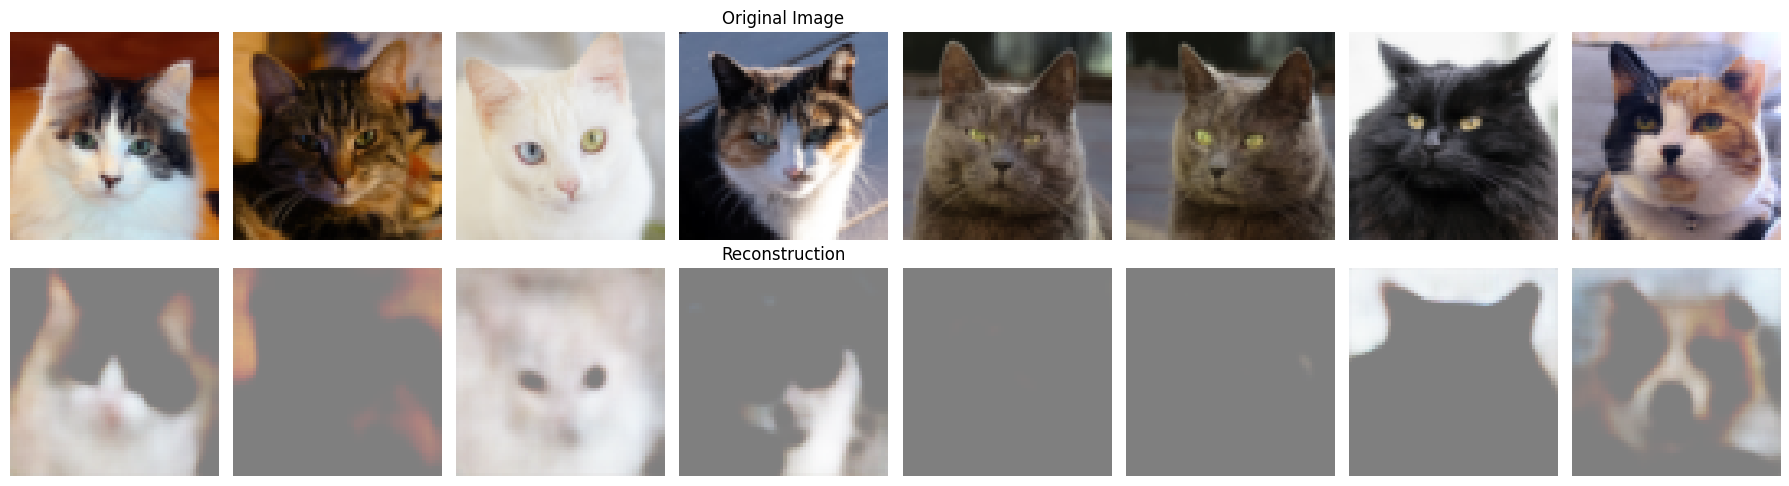

In [5]:
img_vs_recons(model, test_loader, device)

### Inference

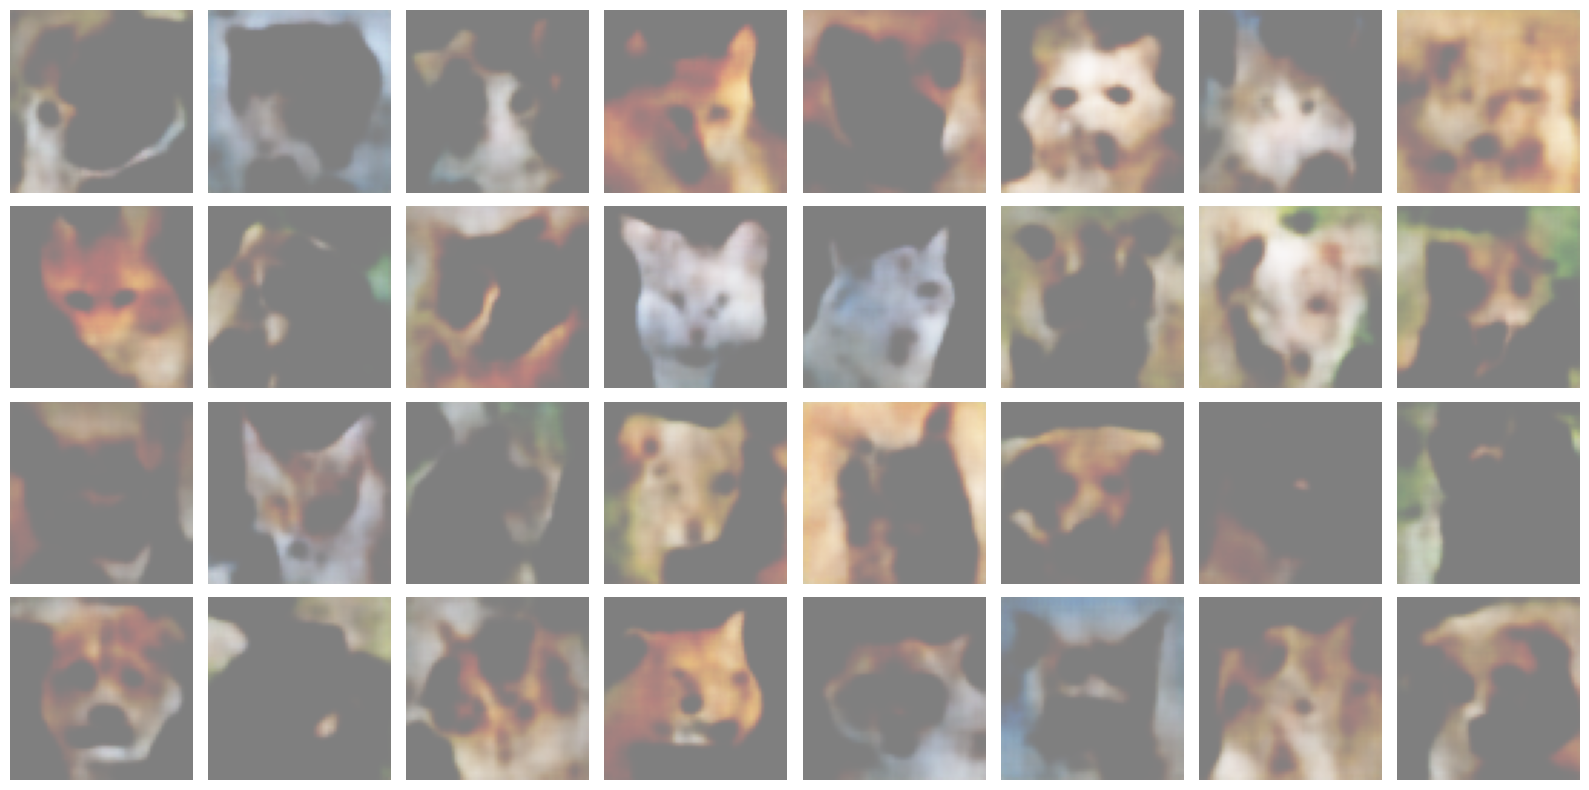

In [6]:
plot_recons(inference(configs,model))


### Latent space  visualization

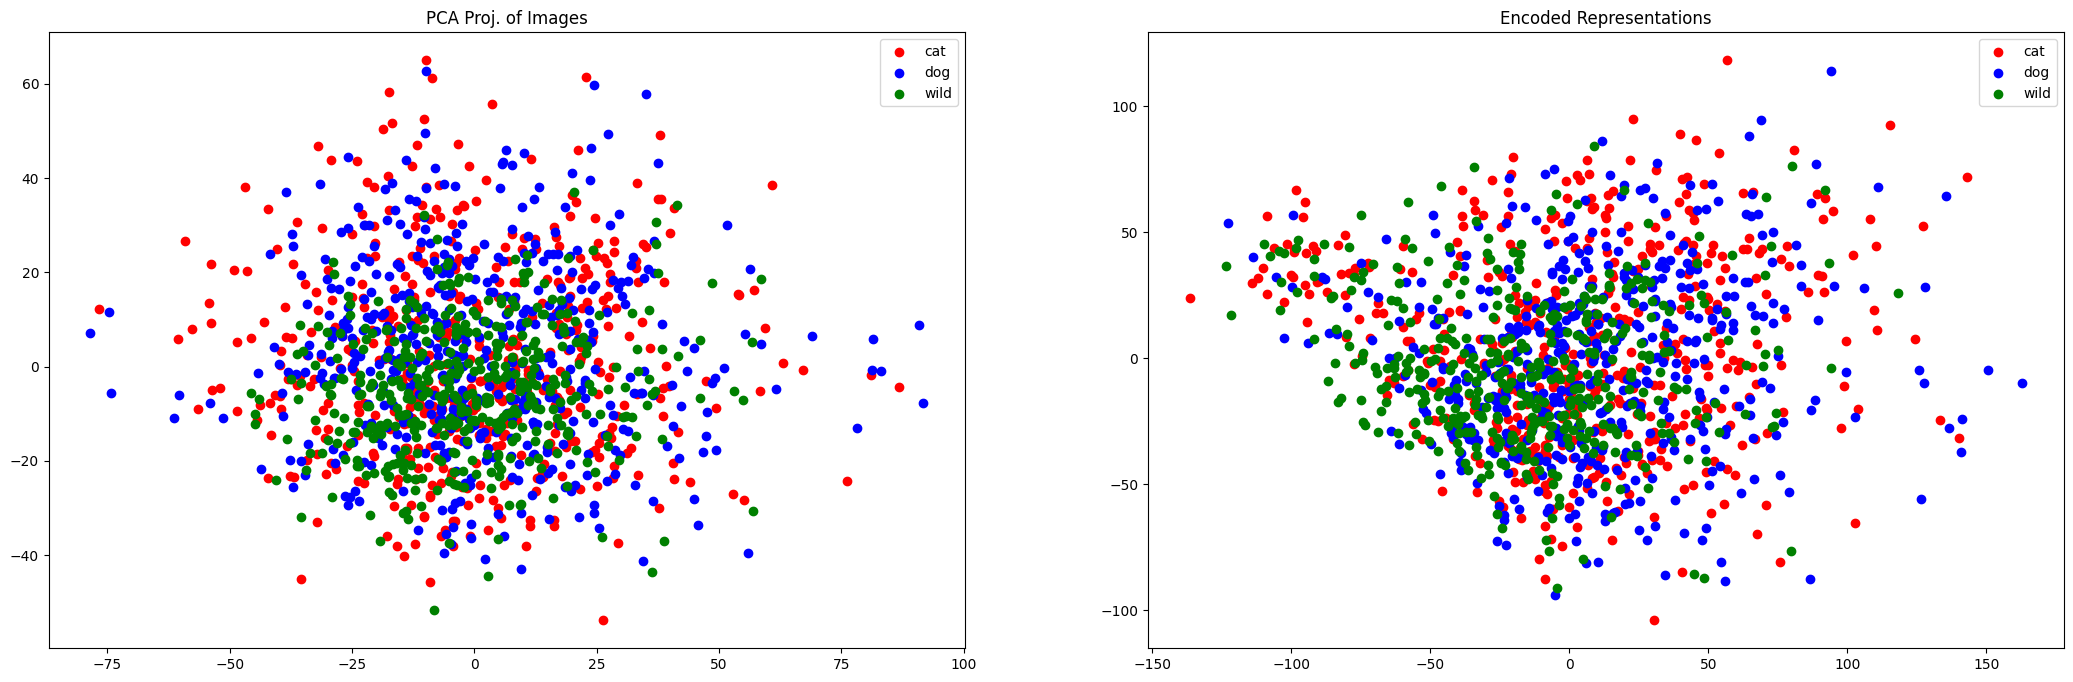

In [7]:
vis_latent(test_loader, model, test_dataset)

### Interpolation

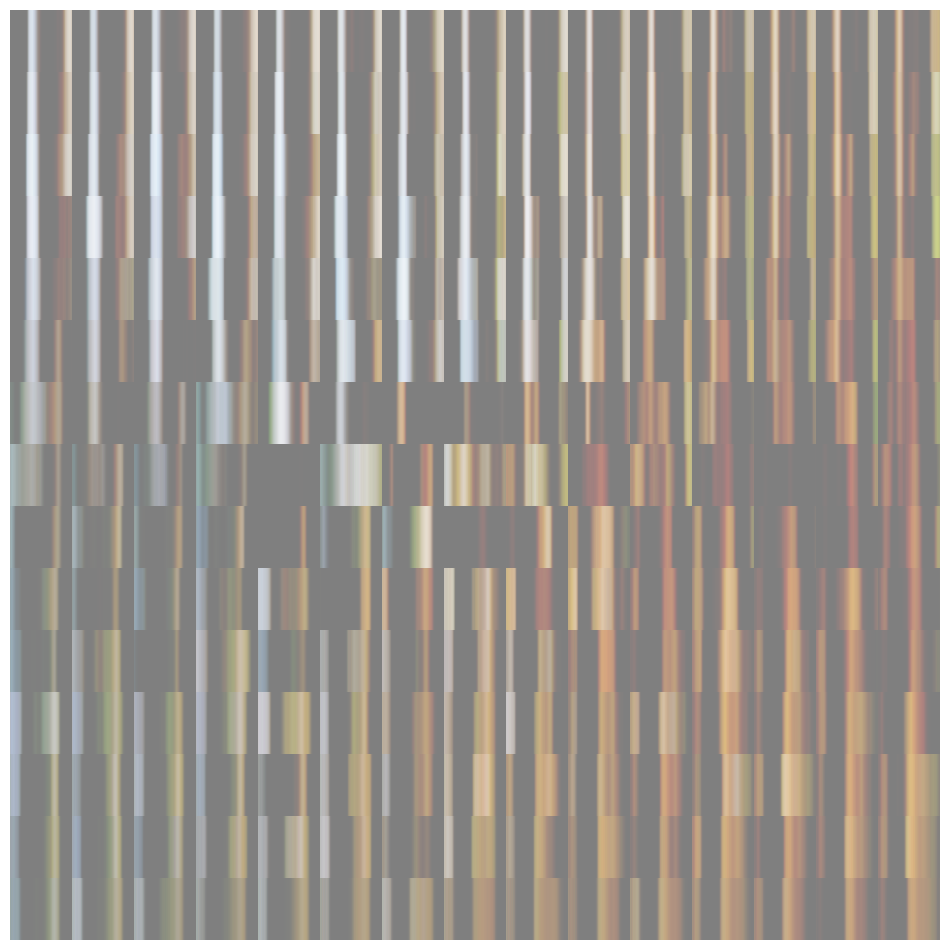

In [5]:
plot_reconstructed(model, xrange=(-50, 50), yrange=(-50, 50), N=15)

## $Analysis$

Although the recons are not maybe the best we can get, the impact of KLD-divegence can obviously be seen the the reconstructed images in tensorboard. Using lambda-kld = 0.0, 1e-4, we could get the best recons, with lambda-kld = 1e-2 showing the poorest performance among others. As mentioned earlier, larger lambda-kld values enforces the network towards learning Guassian distribution, rather that meaningful features.

### **Extra Point:**
 - The ccvae.py network is our extended ConvVAE for Image generation conditioned on a given class. The AFHQ dataset has 3 classes: 'cat', 'dog', and 'wildlife'. 
 
 - Unlike before, during training and inference in this network, we also utilize $labels$ as one-hot encoded vectors being concatinated with the encoded image and fed into the linear layers for mu and sigma. Also, when the decoder wants to generate new samples from latent space, it also needs the given class lable. This is the main difference between the conditioned network and the previous pipeline. Encoding labels will potentially guide the network to learn and generate more reliable generations, as it can also be visualized in the related tensorboard results under the "CCVAE1_KLD_0.0001" name. 